# D — Régression — montants & KPI (EventZilla)

**Cible** : première disponible parmi `final_price`, `service_price`, `benchmark_avg_price`, `event_budget`, `commission_margin`. **X** : autres numériques du wide. **Split** 75/25 ; **CV 5-fold** sur train.

L’objectif est d’**estimer un montant** (ou un KPI dérivé) pour le pilotage : panier moyen, budget événement, marge, etc. Contrairement à la classification, l’erreur se lit en **unités monétaires** (MAE, RMSE) et la qualité globale en **R²** (part de variance expliquée, à nuancer si la cible est très bruitée ou si le test est petit).

**≥ 2 modèles** : **Ridge** (L2, coefficients après scale) vs **Random Forest régresseur** (non-linéaire, importances).

**Grille D** : **MSE, RMSE, MAE, R²** (test) ; CV sur train ; **résidus**, coef Ridge, importances RF ; viz **réel vs prédit**, **résidus vs prédit**, QQ / histo si présents.

**B** : Ridge suppose relation **approximativement linéaire** ; RF sans forme paramétrique — comparer **RMSE test** pour le champion. Détail critère **B** : **`06_B_comprehension_modeles.ipynb`**.

Références : dashboards EventZilla.


## Référence D

Métriques test + **K-Fold** train ; analyse des **résidus** ; explicabilité coef / importances.

En régression, la **CV sur le train** sert à choisir la régularisation Ridge (ou à comparer la stabilité des deux modèles) sans « consommer » le test. Les **résidus** complètent les chiffres : un R² élevé avec résidus structurés (tendance visible) invite à remettre en cause la **linéarité** ou la présence d’**outliers** forts.


## Couverture barème D

| Exigence | Implémentation |
|----------|----------------|
| ≥ 2 modèles | Ridge, RF régresseur |
| Validation | 5-fold sur train ; test 75/25 |
| Métriques | MSE, RMSE, MAE, R² |
| Interprétation | Résidus ; coef Ridge ; importances RF |
| Viz | Réel vs prédit ; résidus vs prédit ; QQ / histo |

Extensions possibles : Lasso, GBR, XGBoost (optionnel).

Pour le rapport, reliez chaque exigence du barème à une **preuve** : tableau de métriques (JSON), figure **réel vs prédit**, et commentaire sur les **résidus** (homoscédasticité approximative, queues épaisses, etc.).


## 1. Connexion DW

Diagnostic aligné SSMS.

Sans la bonne base DW, la requête wide peut retourner un jeu **vide** ou une cible **non comparable** d’un run à l’autre : toujours valider `DB_NAME()` avant d’interpréter Ridge vs RF.


In [1]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

# Connexion DW — diagnostic (même serveur / base que SSMS)
from ML.ml_paths import (
    DATABASE_DW,
    SQL_SERVER,
    SQL_DRIVER,
    SQL_PORT,
    build_windows_auth_uri,
    get_sql_engine,
    ml_sql_only,
    read_dw_sql,
    sql_engine_init_error,
)

print("=" * 62)
print(" EVENTZILLA — Connexion DW (équivalent accès SSMS)")
print("=" * 62)
print("  Serveur SQL      :", SQL_SERVER + (":" + str(SQL_PORT) if SQL_PORT else ""))
print("  Base DW cible    :", DATABASE_DW)
print("  Driver ODBC      :", SQL_DRIVER)
print("  Mode DW seul     :", ml_sql_only(), "(EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)")
try:
    _uri = build_windows_auth_uri()
    print("  Chaîne (extrait) :", (_uri[:88] + "…") if len(_uri) > 88 else _uri)
except Exception as _uerr:
    print("  Chaîne URI       : erreur", _uerr)
_eng = get_sql_engine()
if _eng is not None:
    try:
        _chk = read_dw_sql(
            "SELECT DB_NAME() AS base_active, CAST(SERVERPROPERTY('ServerName') AS NVARCHAR(128)) AS serveur",
            _eng,
        )
        print("  Test SQL         : OK — même base que sous SSMS si base_active =", DATABASE_DW)
        print(_chk.to_string(index=False))
    except Exception as _qerr:
        print("  Test SQL         : ÉCHEC —", _qerr)
else:
    print("  Engine           : ABSENT —", sql_engine_init_error() or "voir pip sqlalchemy pyodbc")
print("=" * 62)


 EVENTZILLA — Connexion DW (équivalent accès SSMS)
  Serveur SQL      : ASUSRANIM
  Base DW cible    : DW_eventzella
  Driver ODBC      : ODBC Driver 17 for SQL Server
  Mode DW seul     : True (EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)
  Chaîne (extrait) : mssql+pyodbc://@ASUSRANIM/DW_eventzella?driver=ODBC+Driver+17+for+SQL+Server&trusted_con…
  Test SQL         : OK — même base que sous SSMS si base_active = DW_eventzella
  base_active   serveur
DW_eventzella AsusRanim


### Après connexion

Serveur / base cohérents avec les autres notebooks.

Si vous travaillez en équipe, notez dans le rapport **serveur + base** utilisés : deux environnements différents peuvent expliquer des écarts de RMSE sans que les algorithmes aient changé.


### Figures + ## 2. Imports & chargement

`%matplotlib inline` si besoin. Charger dépendances régression + jeu `[2]`.

Les figures de régression (nuage réel/prédit, résidus) sont centrales pour le barème **D** : elles montrent **où** le modèle se trompe (gros montants, certaines périodes ou catégories encodées) au-delà des seuls agrégats MSE/R².


In [2]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

%matplotlib inline
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from ML.csv_local_fallback import load_reservation_dataframe
from ML.ml_paths import ML_PROCESSED, ML_MODELS, ensure_processed_dirs, get_sql_engine, ml_sql_only, read_dw_sql
from ML.schema_eventzilla import SQL_ML_FINANCIAL_WIDE, build_sql_ml_financial_wide

ensure_processed_dirs()
ML_MODELS.mkdir(parents=True, exist_ok=True)
print("[1] Régression critère D — Ridge vs RandomForest. ML_SQL_ONLY:", ml_sql_only())


[1] Régression critère D — Ridge vs RandomForest. ML_SQL_ONLY: True


### Après imports

Pipelines Ridge / RF prêts. Puis chargement données (dimensions `[2]`).

Vérifiez que `ML_SQL_ONLY` correspond à votre intention : mode DW strict pour la traçabilité académique, ou repli local uniquement si l’environnement SQL n’est pas disponible.


In [3]:
pp = ML_PROCESSED / "dw_financial_wide.parquet"
if pp.is_file():
    df = pd.read_parquet(pp)
    print("[2] Source : dw_financial_wide.parquet (critère A, après connexion SSMS)")
else:
    eng = get_sql_engine()
    if eng is None:
        if ml_sql_only():
            raise RuntimeError("[2] Pas de parquet DW et pas de SQL (EVENTZILLA_ML_SQL_ONLY=1). Exécuter le critère A (`00_A_preparation_donnees_feature_engineering.ipynb`).")
        df = load_reservation_dataframe()
        print("[2] Source : Reservation (local, ML_SQL_ONLY=0)")
    else:
        try:
            q_fin = build_sql_ml_financial_wide(eng)
            df = read_dw_sql(q_fin, eng)
            print("[2] Source : SQL DW (requête adaptée)")
        except Exception as e:
            print("[2] SQL dynamique indisponible, essai statique :", e)
            try:
                df = read_dw_sql(SQL_ML_FINANCIAL_WIDE, eng)
                print("[2] Source : SQL DW (statique)")
            except Exception as e2:
                if ml_sql_only():
                    raise RuntimeError("[2] DW inaccessible (dynamique + statique) : " + str(e2)) from e2
                print("[2] SQL statique échoué, local :", e2)
                df = load_reservation_dataframe()
print("[2] Dimensions :", df.shape)


[2] Source : dw_financial_wide.parquet (critère A, après connexion SSMS)
[2] Dimensions : (20142, 16)


## 3. Matrice X, y et split train / test

**Objectif** : cible `y` (priorité KPI), matrice `X`, split 75/25.

### Après chargement des données

La sortie `[2]` indique la source (parquet / SQL) et les dimensions.

### Après construction X, y

Vérifier le nom de la cible, `n` et le nombre de features avant la CV.

La **première cible disponible** dans la liste prioritaire évite les échecs si une colonne manque en base, mais impose de **lire** la sortie `[3]` : le commentaire métier du rapport doit nommer explicitement **quel** KPI a été modélisé (prix final, budget, etc.).


In [4]:
MIN_ROWS = 30
df_reg = df.copy()
if (
    "final_price" in df_reg.columns
    and "service_price" in df_reg.columns
    and "commission_margin" not in df_reg.columns
):
    df_reg["commission_margin"] = (
        pd.to_numeric(df_reg["final_price"], errors="coerce")
        - pd.to_numeric(df_reg["service_price"], errors="coerce")
    )
TARGET_ORDER = [
    "final_price",
    "service_price",
    "benchmark_avg_price",
    "event_budget",
    "commission_margin",
]
primary_target = None
for t in TARGET_ORDER:
    if t in df_reg.columns:
        primary_target = t
        break
if primary_target is None:
    raise ValueError("[3] Aucune colonne cible régression reconnue.")
yraw = pd.to_numeric(df_reg[primary_target], errors="coerce")
oth = [c for c in df_reg.select_dtypes(include=[np.number]).columns if c != primary_target and c != "fact_finance_id"]
block = pd.concat([yraw, df_reg[oth]], axis=1).dropna()
if len(block) < MIN_ROWS or block[primary_target].std(skipna=True) == 0 or not oth:
    raise ValueError("[3] Pas assez de données ou variance nulle pour " + primary_target)
feat_names = list(oth)
y = block[primary_target].values
X = block[oth].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
print("[3] Cible :", primary_target, "| n=", len(block), "| features=", len(feat_names))
kpi_tag = {
    "final_price": "panier_moyen_ca_sum_final_price",
    "service_price": "prix_prestataire_structure_revenus",
    "benchmark_avg_price": "positionnement_tarifaire_benchmark",
    "event_budget": "budget_evenement",
    "commission_margin": "marge_finale_moins_prestataire_commission",
}.get(primary_target, "regression_kpi")


[3] Cible : final_price | n= 20142 | features= 12


### Après matrice

Train/test prêts pour CV §4.

Un test trop petit rend le **RMSE** bruyant ; en cas d’échantillon modeste, accordez plus de poids à la **CV train** et à la forme des **résidus** qu’à un écart faible RMSE entre Ridge et RF.


## 4. Entraînement & CV

**CV** : stabilité RMSE / R² / MAE sur train. Puis comparaison **test** §5.

**Interprétation graphiques (après code)** :

| Graphique | Lecture |
|-----------|---------|
| **Réel vs prédit** | Points sur diagonale = bon ajustement ; nuage hors diagonale = biais / non-linéarité |
| **Résidus vs prédit** | Motte aléatoire autour 0 = homoscédasticité plausible ; motif en U → structure non captée |
| **QQ / histo résidus** | Approximation normalité des erreurs (surtout pour lecture Ridge) |
| **Coef / importances** | Levier métier relatif (variables standardisées pour Ridge) |

**Synthèse** : si le nuage **réel vs prédit** s’aligne sur la diagonale surtout pour la RF mais pas pour Ridge, le phénomène est probablement **non linéaire** (seuils, interactions) ; l’inverse suggère une structure **presque linéaire** où Ridge peut suffire avec une meilleure **lisibilité** des leviers.


### Modèle 1 — Ridge

CV 5-fold sur train — référence **linéaire régularisée**.

Ridge **rétracte** les coefficients corrélés entre eux : utile quand le wide contient plusieurs montants ou indicateurs proches. Les coefficients après scaling indiquent la direction d’effet sur la cible, sous l’hypothèse de linéarité.


In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
pipe_ridge = Pipeline([("scale", StandardScaler()), ("reg", Ridge(alpha=1.0))])
pipe_rf = Pipeline([
    ("scale", StandardScaler()),
    ("reg", RandomForestRegressor(n_estimators=120, random_state=42)),
])


def cv_scores(name, pipe):
    mse = -cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="neg_mean_squared_error")
    r2s = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="r2")
    neg_mae = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="neg_mean_absolute_error")
    return {
        "model": name,
        "cv_rmse_mean": float(np.sqrt(mse.mean())),
        "cv_rmse_std": float(np.sqrt(mse.std())),
        "cv_r2_mean": float(r2s.mean()),
        "cv_mae_mean": float(-neg_mae.mean()),
    }


print("[4] Validation croisée (5-fold) sur TRAIN uniquement :")
sr = cv_scores("Ridge", pipe_ridge)


[4] Validation croisée (5-fold) sur TRAIN uniquement :


### Modèle 2 — Random Forest

CV sur train — comparer lignes **Ridge vs RF** dans la sortie `[4]`.

La RF peut réduire le biais sur des relations **par morceaux** (paliers de prix selon la date ou la catégorie) au prix d’un modèle moins parcimonieux. Comparez les **importances** aux signes des coef Ridge pour une lecture croisée barème **D** (explicabilité).


In [6]:
sf = cv_scores("RandomForest", pipe_rf)
print("    Ridge   — CV RMSE:", round(sr["cv_rmse_mean"], 4), "| CV R²:", round(sr["cv_r2_mean"], 4))
print("    RF      — CV RMSE:", round(sf["cv_rmse_mean"], 4), "| CV R²:", round(sf["cv_r2_mean"], 4))


    Ridge   — CV RMSE: 2.0152 | CV R²: 1.0
    RF      — CV RMSE: 842.8229 | CV R²: 0.9972


## 5. Comparaison test

**Champion** : typiquement **RMSE test** minimal (vérifier dans le code).

**Relier** : métriques tableaux ↔ figures résidus / réel-prédit.

Un R² très proche de1 mérite vigilance (fuite de cible, doublons, ou cible presque déterministe dans `X`) : croisez toujours avec des graphes et la liste des colonnes utilisées.


[4] TEST Ridge   : {'mse': 2.59009, 'rmse': 1.60938, 'mae': 0.70773, 'r2': 1.0}
[4] TEST RF      : {'mse': 242238.00045, 'rmse': 492.1768, 'mae': 95.38928, 'r2': 0.99904}
[4] Champion (RMSE test minimal) : Ridge


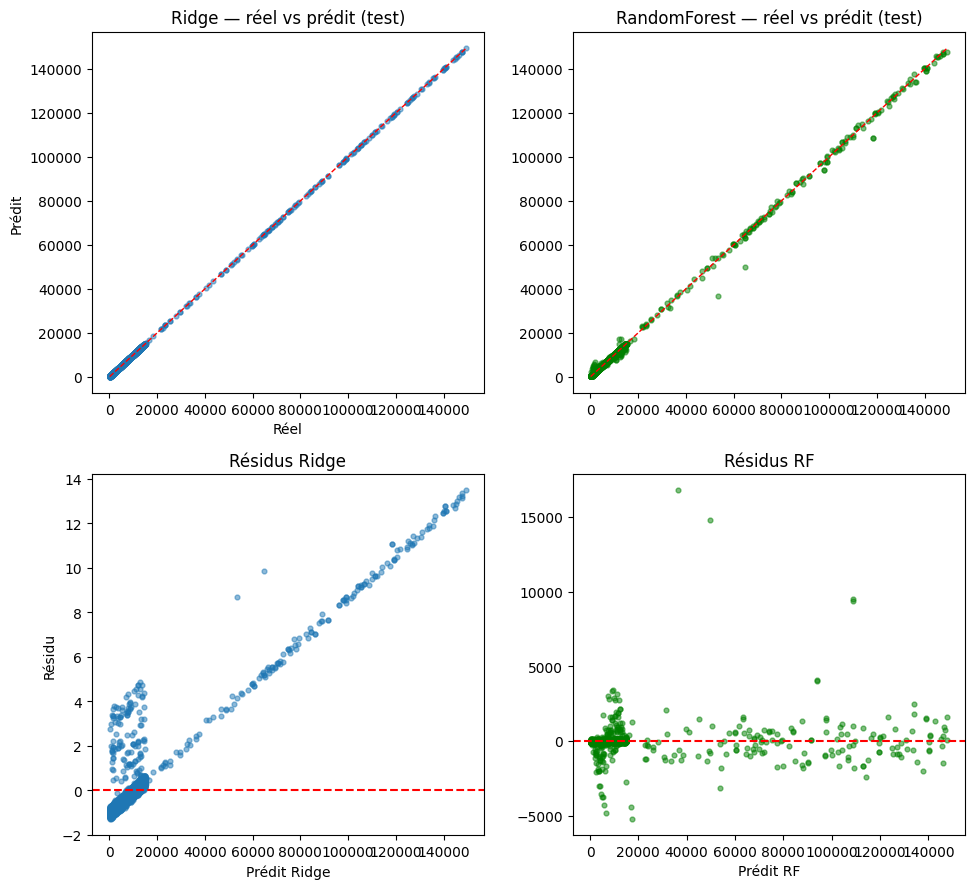

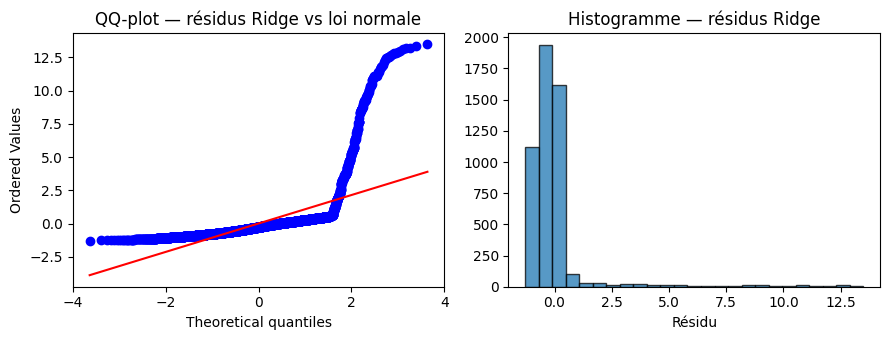

[4b] Résidus Ridge — skew: 5.2544 | excès kurtosis: 31.6134
     QQ ~ droite et skew/kurtosis proches de 0 → résidus proches d'une normale (hypothèses OLS/Ridge plus crédibles).


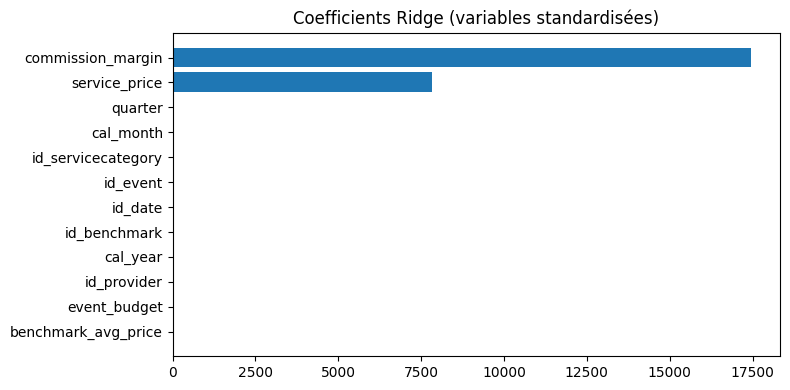

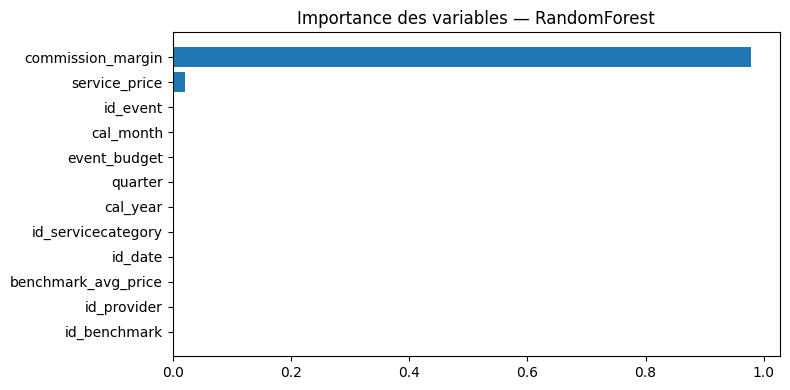

In [7]:
pipe_ridge.fit(Xtr, ytr)
pipe_rf.fit(Xtr, ytr)
pr_r = pipe_ridge.predict(Xte)
pr_f = pipe_rf.predict(Xte)


def test_metrics(pred):
    mse = mean_squared_error(yte, pred)
    return {
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(yte, pred)),
        "r2": float(r2_score(yte, pred)),
    }


tr = test_metrics(pr_r)
tf = test_metrics(pr_f)
print("[4] TEST Ridge   :", {k: round(v, 5) for k, v in tr.items()})
print("[4] TEST RF      :", {k: round(v, 5) for k, v in tf.items()})

if tr["rmse"] <= tf["rmse"]:
    champion, champ_name, pred_ch = pipe_ridge, "Ridge", pr_r
else:
    champion, champ_name, pred_ch = pipe_rf, "RandomForest", pr_f
print("[4] Champion (RMSE test minimal) :", champ_name)

fig, ax = plt.subplots(2, 2, figsize=(10, 9))
ax[0, 0].scatter(yte, pr_r, alpha=0.5, s=12)
ax[0, 0].plot([yte.min(), yte.max()], [yte.min(), yte.max()], "r--", lw=1)
ax[0, 0].set_xlabel("Réel")
ax[0, 0].set_ylabel("Prédit")
ax[0, 0].set_title("Ridge — réel vs prédit (test)")
ax[0, 1].scatter(yte, pr_f, alpha=0.5, s=12, color="green")
ax[0, 1].plot([yte.min(), yte.max()], [yte.min(), yte.max()], "r--", lw=1)
ax[0, 1].set_title("RandomForest — réel vs prédit (test)")
res_r = yte - pr_r
res_f = yte - pr_f
ax[1, 0].scatter(pr_r, res_r, alpha=0.5, s=12)
ax[1, 0].axhline(0, color="r", ls="--")
ax[1, 0].set_xlabel("Prédit Ridge")
ax[1, 0].set_ylabel("Résidu")
ax[1, 0].set_title("Résidus Ridge")
ax[1, 1].scatter(pr_f, res_f, alpha=0.5, s=12, color="green")
ax[1, 1].axhline(0, color="r", ls="--")
ax[1, 1].set_xlabel("Prédit RF")
ax[1, 1].set_title("Résidus RF")
plt.tight_layout()
plt.show()

# Contrôle d'hypothèses (résidus du modèle linéaire Ridge : normalité approx., symétrie)
try:
    from scipy import stats as _st

    _figq, _axq = plt.subplots(1, 2, figsize=(9, 3.5))
    _st.probplot(res_r, dist="norm", plot=_axq[0])
    _axq[0].set_title("QQ-plot — résidus Ridge vs loi normale")
    _nb = min(25, max(8, len(res_r) // 3))
    _axq[1].hist(res_r, bins=_nb, edgecolor="k", alpha=0.75)
    _axq[1].set_title("Histogramme — résidus Ridge")
    _axq[1].set_xlabel("Résidu")
    plt.tight_layout()
    plt.show()
    _sk = float(_st.skew(res_r))
    _ku = float(_st.kurtosis(res_r, fisher=True))
    print("[4b] Résidus Ridge — skew:", round(_sk, 4), "| excès kurtosis:", round(_ku, 4))
    print("     QQ ~ droite et skew/kurtosis proches de 0 → résidus proches d'une normale (hypothèses OLS/Ridge plus crédibles).")
except ImportError:
    print("[4b] Installez scipy pour QQ-plot et moments des résidus (pip install scipy).")

coef = pipe_ridge.named_steps["reg"].coef_
idx = np.argsort(np.abs(coef))[-min(15, len(coef)) :]
plt.figure(figsize=(8, 4))
plt.barh(np.array(feat_names)[idx], coef[idx])
plt.title("Coefficients Ridge (variables standardisées)")
plt.tight_layout()
plt.show()

imp = pipe_rf.named_steps["reg"].feature_importances_
idx2 = np.argsort(imp)[::-1][:15]
plt.figure(figsize=(8, 4))
plt.barh(np.array(feat_names)[idx2][::-1], imp[idx2][::-1])
plt.title("Importance des variables — RandomForest")
plt.tight_layout()
plt.show()


### Après comparaison test

| Métrique | Lecture |
|----------|---------|
| **R²** | Part de variance expliquée (1 = parfait sur l’échantillon) |
| **RMSE / MAE** | Erreur en unité de la cible ; RMSE pénalise les gros écarts |
| **Résidus** | Motif régulier → modèle sous-ajusté ou mauvaise spécification |

Champion = meilleur compromis selon la règle du notebook (souvent RMSE test).

Si le champion change selon que l’on privilégie **MAE** (erreur moyenne robuste aux extrêmes) ou **RMSE** (sensible aux gros écarts), documentez le **coût métier** associé aux outliers.



In [8]:
joblib.dump(pipe_ridge, ML_MODELS / "ridge_regression_primary.joblib")
joblib.dump(pipe_rf, ML_MODELS / "rf_regression_primary.joblib")
joblib.dump(champion, ML_MODELS / "rf_panier_kpi_pipeline.joblib")

(ML_MODELS / "metrics_regression.json").write_text(
    json.dumps({
        "task": "regression",
        "criterion": "D",
        "champion_model": champ_name,
        "target": primary_target,
        "kpi_alignment": kpi_tag,
        "features": feat_names,
        "cv_ridge": sr,
        "cv_random_forest": sf,
        "test_ridge": tr,
        "test_random_forest": tf,
        "test_champion": tr if champ_name == "Ridge" else tf,
    }, indent=2),
    encoding="utf-8",
)
print("[5] ridge_regression_primary.joblib, rf_regression_primary.joblib, rf_panier_kpi_pipeline (=champion), metrics_regression.json")


[5] ridge_regression_primary.joblib, rf_regression_primary.joblib, rf_panier_kpi_pipeline (=champion), metrics_regression.json


### Après exécution — lecture (fichiers produits)

Modèles sérialisés et **JSON** des métriques pour la synthèse projet.

Ces fichiers alimentent **`05_synthese_metriques_validation.ipynb`** et le déploiement : gardez les mêmes noms et la même procédure d’export pour que la synthèse reste **reproductible**.
